## 1. Installation

In [1]:
!pip install -q paddlepaddle==3.2.2 paddleocr

import paddle
from importlib.metadata import version
print("paddleocr version :", version("paddleocr"))
print("paddle version :", paddle.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 1.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 9.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 24.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 52.5 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 72.4 MB/s eta 0:00:00:00:01

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


paddleocr version : 3.7.0
paddle version : 3.2.2


**Important** : si tu as deja installe une autre version de `paddlepaddle` / `paddlepaddle-gpu` dans cette session
auparavant, il faut faire un **Factory reset session** (Settings/menu session) avant de lancer cette cellule.
Un simple "Restart session" ne suffit pas toujours car certains paquets systeme (ex. libs nvidia-cu12) restent en place
sur le disque et peuvent entrer en conflit.

## 2. Verifier le dataset Kaggle

Sur Kaggle, les fichiers d'un dataset ajoute au notebook sont montes en lecture seule sous `/kaggle/input/<nom-du-dataset>/`. On liste le contenu pour confirmer le chemin exact avant de continuer (utile si le PDF est dans un sous-dossier).

In [2]:
import os

# Etape 1 : lister tous les datasets disponibles sous /kaggle/input
print("Datasets disponibles dans /kaggle/input :")
for name in os.listdir("/kaggle/input"):
    print(" -", name)

Datasets disponibles dans /kaggle/input :
 - datasets


In [3]:
# Etape 2 : exploration recursive complete pour trouver tous les PDF,
# quelle que soit la profondeur des sous-dossiers
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower().endswith(".pdf"):
            print(os.path.join(root, f))

/kaggle/input/datasets/hasnaasaadi/my-dataset3/loan_0001.pdf


## 3. Configuration des parametres de lecture

Les options principales se reglent a la creation de l'objet `PaddleOCR` (langue, orientation, device).

**Difference avec EasyOCR** : PaddleOCR charge un modele par langue (pas de liste de langues combinees comme `["fr","en","de"]`). Pour un document majoritairement en allemand, on choisit `lang="german"`. Si le document melange vraiment plusieurs langues latines de maniere significative, il existe un modele `lang="latin"` (couvre plusieurs langues latines dont le francais et l'allemand) mais avec une precision generalement plus faible qu'un modele mono-langue.

**Note API (PaddleOCR >= 3.0)** : depuis la version 3.x (moteur PaddleX), `use_angle_cls`/`use_gpu` sont remplaces par `use_textline_orientation`/`device`, et `.ocr()` est depreciee au profit de `.predict()`.

**CPU uniquement** : on reste volontairement sur `DEVICE = "cpu"` pour eviter les conflits de versions CUDA entre PaddlePaddle et les autres librairies GPU deja presentes sur l'image Kaggle (torch, etc.). Pour un seul PDF de quelques pages, la difference de temps CPU/GPU est negligeable.

In [4]:
from paddleocr import PaddleOCR

# --- Langue ---
LANG = "german"

# --- Orientation des lignes de texte (remplace l'ancien use_angle_cls) ---
USE_TEXTLINE_ORIENTATION = True

# --- Device ---
DEVICE = "cpu"

ocr = PaddleOCR(
    lang=LANG,
    use_textline_orientation=USE_TEXTLINE_ORIENTATION,
    device=DEVICE,
    use_doc_orientation_classify=False,  # page deja bien orientee (scan/PDF standard)
    use_doc_unwarping=False,             # pas de deformation a corriger
)
print("Reader PaddleOCR pret.")

Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_det', None, None)
Using official model (PP-OCRv6_medium_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_det`.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Reader PaddleOCR pret.


## 4. Lecture du PDF et conversion en images

Chemin adapte a Kaggle : `/kaggle/input/<dataset>/...` pour la lecture (lecture seule).

Comme EasyOCR, PaddleOCR travaille sur des images. Chaque page du PDF est donc convertie en image avec `pdf2image`, qui s'appuie sur le binaire `poppler` (installe via `apt-get` dans la cellule suivante, car absent par defaut de certaines images Kaggle) avant de lancer l'OCR.

In [5]:
# Adapte le nom de fichier si besoin, d'apres la sortie de la cellule 2
DATASET_DIR = "/kaggle/input/datasets/hasnaasaadi/my-dataset3"
PDF_PATH = os.path.join(DATASET_DIR, "loan_0001.pdf")

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# pdf2image s'appuie sur le binaire "poppler" (pdfinfo, pdftoppm), absent par defaut
# de certaines images Kaggle -> on l'installe via apt avant d'utiliser pdf2image.
!apt-get update -qq && apt-get install -y -qq poppler-utils
!pip install -q pdf2image

from pdf2image import convert_from_path

pages = convert_from_path(PDF_PATH, dpi=200)
image_paths = []
for i, page in enumerate(pages):
    img_path = os.path.join(OUTPUT_DIR, f"page_{i+1}.png")
    page.save(img_path, "PNG")
    image_paths.append(img_path)

print("Pages converties en images :", image_paths)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../libpoppler-private-dev_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking libpoppler-private-dev:amd64 (22.02.0-2ubuntu0.13) over (22.02.0-2ubuntu0.12) ...
Preparing to unpack .../libpoppler-dev_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking libpoppler-dev:amd64 (22.02.0-2ubuntu0.13) over (22.02.0-2ubuntu0.12) ...
Preparing to unpack .../libpoppler118_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking libpoppler118:amd64 (22.02.0-2ubuntu0.13) over (22.02.0-2ubuntu0.12) ...
Selecting previously unselected package poppler-utils.
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.13) ...
Setting up libpoppler118:amd64 (22.02.0-2ubuntu0.13) ...
Setting up poppler-

## 5. Execution de l'OCR

`ocr.predict(img_path)` renvoie, pour chaque page, une liste contenant un objet resultat avec les cles
`rec_texts` (textes), `rec_scores` (confiances) et `rec_polys` (positions). On normalise ces resultats dans
la meme liste `all_results` que pour les autres moteurs afin de garder un export identique.

In [6]:
all_results = []  # liste de dicts : page, bbox, texte, confiance

for page_num, img_path in enumerate(image_paths, start=1):
    result = ocr.predict(img_path)
    res = result[0] if result else None

    texts = res["rec_texts"] if res else []
    scores = res["rec_scores"] if res else []
    polys = res["rec_polys"] if res else []

    print(f"Page {page_num} : {len(texts)} zones de texte detectees")
    for bbox, text, conf in zip(polys, texts, scores):
        all_results.append({
            "page": page_num,
            "bbox": bbox,
            "text": text,
            "confidence": conf,
        })

print("\nTotal zones detectees :", len(all_results))

ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
Page 1 : 50 zones de texte detectees
Page 2 : 2 zones de texte detectees

Total zones detectees : 52


## 6. Export du contenu

Le Markdown est le plus lisible, le JSON (avec positions et scores) est le plus complet pour un traitement automatique en aval — meme logique que pour EasyOCR et Docling.

In [7]:
# Construction du Markdown, page par page
md_text = ""
current_page = None
for r in all_results:
    if r["page"] != current_page:
        current_page = r["page"]
        md_text += f"\n\n## Page {current_page}\n\n"
    md_text += r["text"] + "\n"

print(md_text)



## Page 1

Loan Application for a Commercial Real Estate
Loan - Company Profile
1. Applicant
Company Name
Söding GmbH & Co. KGaA UG
Legal Form
Limited Partnership (KG)
Date of Incorporation
01/12/2006
Business Address
Falk-Textor-Weg 160, 86608 Gransee, Germany
Commercial Register Number / Court
HRB 977141 / Gransee Local Court
VAT ID / Tax Number
DE681242882
2. Financial Request / Property Description
Type of Property
Office and Commercial Building
Property Name
Werden Center Gransee
Adress
Laszlo-Hiller-Allee 29, 79030 Gransee, Germany
Purchase Price / Construction Costs
€1,337,000
Desired Financing Amount
€944,000
Purpose of Use
Modernization
Equity Contribution
€393,000
Year of Construction
1990
Total Area
3,133 m²
3. Financing Proposal
Desired Loan Amount
€944,000
Term
25 years
Preferred Installment Amount
€4,100 per month
Interest Rate
Variable
Early Repayment Desired?
[ ] yes [x] no
Public Subsidies Applied For?
[x] yes [ ] no
4. Declaration & Signature
I hereby confirm the ac

In [8]:
# Sauvegarde en Markdown dans /kaggle/working (seul dossier ecriture autorisee sur Kaggle)
md_out_path = os.path.join(OUTPUT_DIR, "loan_0001_paddleocr.md")

with open(md_out_path, "w", encoding="utf-8") as f:
    f.write(md_text)

print("Sauvegarde OK :", md_out_path)

Sauvegarde OK : /kaggle/working/loan_0001_paddleocr.md


In [9]:
# JSON complet (texte + positions + confiance), utile pour extraire des champs automatiquement
import json

# bbox est un tableau numpy de 4 points [x, y] -> conversion en liste de listes d'int pour le JSON
json_ready = [
    {
        "page": r["page"],
        "text": r["text"],
        "confidence": float(r["confidence"]),
        "bbox": [[int(x), int(y)] for x, y in r["bbox"]],
    }
    for r in all_results
]

json_out_path = os.path.join(OUTPUT_DIR, "loan_0001_paddleocr.json")
with open(json_out_path, "w", encoding="utf-8") as f:
    json.dump(json_ready, f, ensure_ascii=False, indent=2)

print("JSON sauvegarde :", json_out_path)

JSON sauvegarde : /kaggle/working/loan_0001_paddleocr.json


## 7. Parcourir les elements avec leurs positions (bounding boxes)

Chaque zone detectee a un texte, un score de confiance et des coordonnees sur la page. Utile pour relier une valeur extraite a son emplacement physique.

In [10]:
for r in all_results:
    print(f"[page {r['page']}] conf {r['confidence']:.2f} | bbox {r['bbox']}")
    print("   ", r["text"][:90])

[page 1] conf 1.00 | bbox [[154 165]
 ...
 [154 225]]
    Loan Application for a Commercial Real Estate
[page 1] conf 1.00 | bbox [[153 230]
 ...
 [153 291]]
    Loan - Company Profile
[page 1] conf 1.00 | bbox [[157 367]
 ...
 [157 406]]
    1. Applicant
[page 1] conf 1.00 | bbox [[171 446]
 ...
 [171 477]]
    Company Name
[page 1] conf 0.99 | bbox [[723 446]
 ...
 [723 476]]
    Söding GmbH & Co. KGaA UG
[page 1] conf 1.00 | bbox [[170 507]
 ...
 [170 539]]
    Legal Form
[page 1] conf 1.00 | bbox [[722 505]
 ...
 [722 536]]
    Limited Partnership (KG)
[page 1] conf 1.00 | bbox [[172 568]
 ...
 [172 596]]
    Date of Incorporation
[page 1] conf 1.00 | bbox [[723 568]
 ...
 [723 596]]
    01/12/2006
[page 1] conf 1.00 | bbox [[173 630]
 ...
 [173 657]]
    Business Address
[page 1] conf 1.00 | bbox [[722 627]
 ...
 [722 657]]
    Falk-Textor-Weg 160, 86608 Gransee, Germany
[page 1] conf 0.99 | bbox [[172 689]
 ...
 [172 719]]
    Commercial Register Number / Court
[page 1] conf 1.00

## 8. Visualiser les detections sur l'image

Utile pour verifier visuellement que l'OCR detecte bien les bonnes zones (par exemple les cases d'un formulaire de credit).

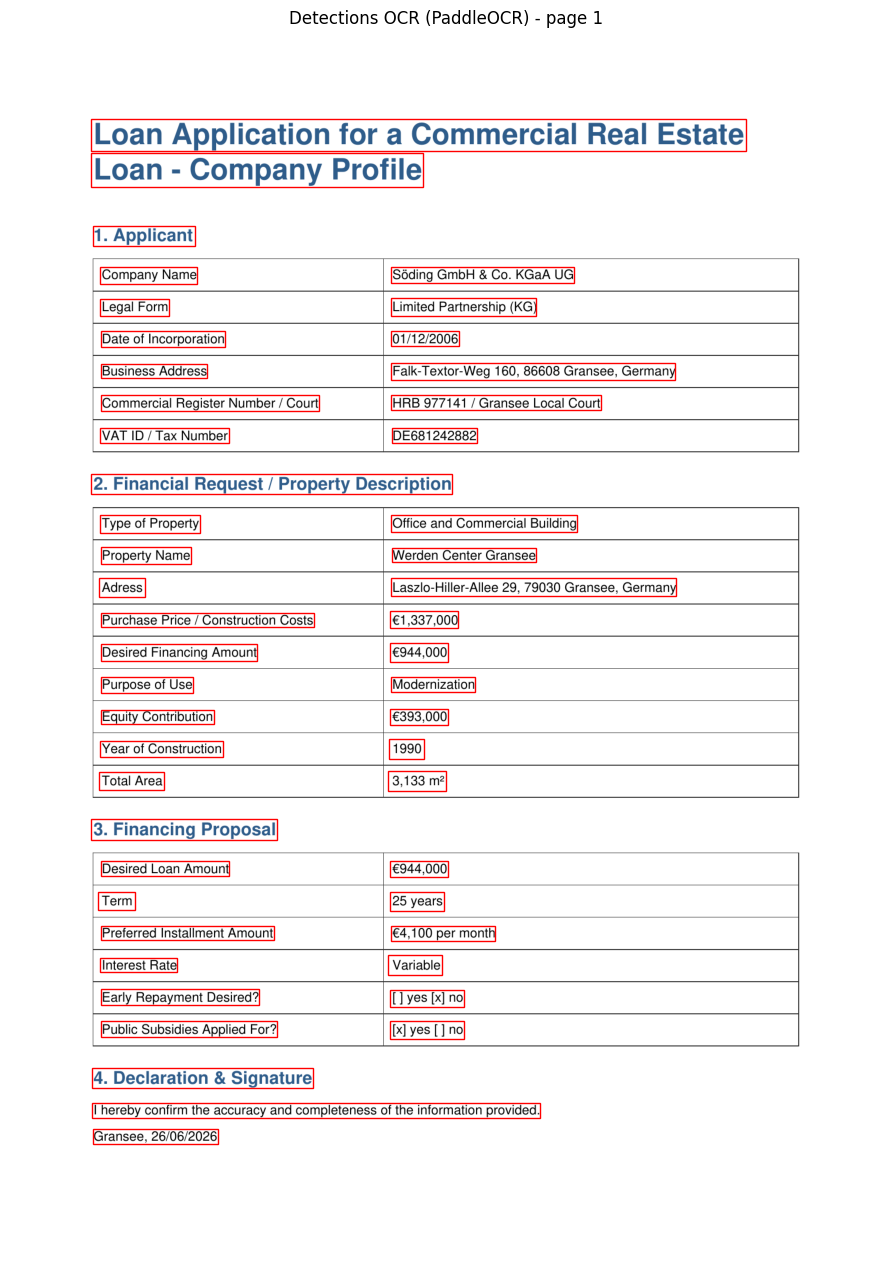

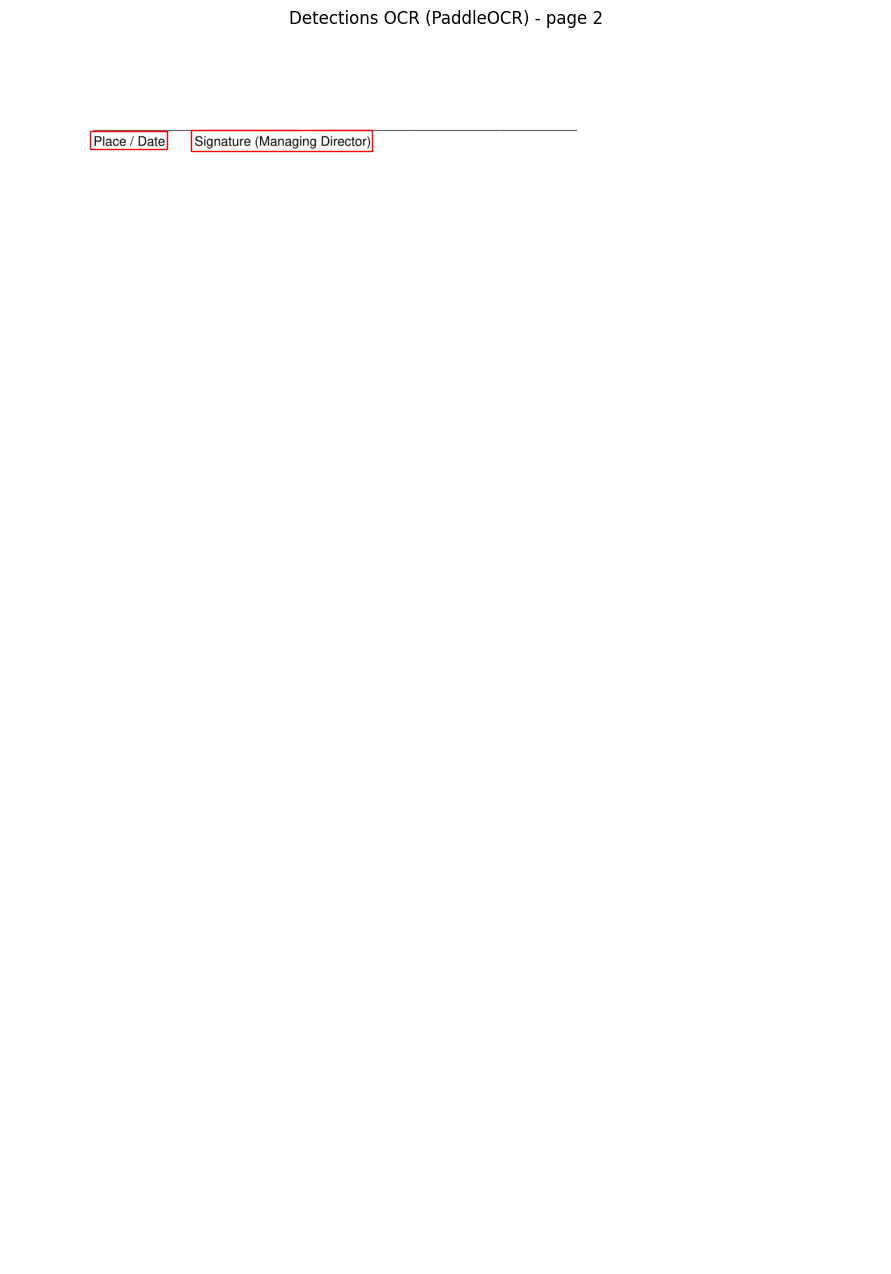

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Affiche toutes les pages, une a une
for page_num, img_path in enumerate(image_paths, start=1):
    img = Image.open(img_path)

    fig, ax = plt.subplots(figsize=(12, 16))
    ax.imshow(img)

    for r in all_results:
        if r["page"] != page_num:
            continue
        bbox = r["bbox"]
        xs = [p[0] for p in bbox]
        ys = [p[1] for p in bbox]
        x0, y0 = min(xs), min(ys)
        w, h = max(xs) - x0, max(ys) - y0
        rect = patches.Rectangle((x0, y0), w, h, linewidth=1, edgecolor="red", facecolor="none")
        ax.add_patch(rect)

    ax.set_title(f"Detections OCR (PaddleOCR) - page {page_num}")
    ax.axis("off")
    plt.show()

## 9. Recuperer les resultats sous forme de tableau

Pratique pour filtrer, trier ou croiser les zones detectees (par exemple ne garder que les textes avec une confiance elevee).

In [ ]:
import pandas as pd

df = pd.DataFrame(all_results)
df.head(20)

## Resume des chemins Kaggle

- Lecture (input, lecture seule) : `/kaggle/input/<dataset>/...`
- Ecriture (output) : `/kaggle/working/...` -> c'est ce dossier qui apparait ensuite dans l'onglet "Output" du notebook Kaggle une fois execute/commit

## Resume des parametres principaux

- `paddlepaddle==3.2.2` : version pinnee pour eviter le bug oneDNN/PIR de la 3.3.0 sur CPU
- `LANG = "german"` : une seule langue par modele avec PaddleOCR (contrairement a la liste `["fr","en","de"]` d'EasyOCR)
- `USE_TEXTLINE_ORIENTATION = True` : classification de l'orientation des lignes de texte
- `DEVICE = "cpu"` : execution CPU volontaire pour eviter les conflits de versions CUDA avec les autres librairies (torch) presentes sur l'image Kaggle
- Les PDF sont convertis en images page par page (`pdf2image`) avant l'OCR, car PaddleOCR (comme EasyOCR) ne lit que des images
- Sorties utiles : `loan_0001_paddleocr.md` (texte), `loan_0001_paddleocr.json` (texte + bbox + confiance), `df` (pandas)

## En cas d'erreurs persistantes

- `NotImplementedError: ConvertPirAttribute2RuntimeAttribute...` -> verifier que `paddlepaddle==3.2.2` est bien installe (pas 3.3.x), et faire un **Factory reset session** si une autre version a deja ete chargee dans cette session.
- `PDX has already been initialized` -> redemarrer/reset la session avant de re-executer la cellule 3.
- `PackageNotFoundError: paddlepaddle` -> normal si tu as installe `paddlepaddle-gpu` : le nom du paquet PyPI differe, mais le module a importer reste `paddle` dans les deux cas.